# Detecção de Câncer de Colo do Útero — EDA e Treinamento dos Modelos ML

**Dataset:** UCI Cervical Cancer Risk Factors  
**Fonte:** `data/raw/risk_factors_cervical_cancer.csv`  
**Target:** coluna `Biopsy` (0 = negativo, 1 = positivo para câncer)

Este notebook cobre:
1. Carregamento e Exploração dos Dados
2. Visualizações
3. Pré-processamento
4. Treinamento de 3 modelos: Logistic Regression, Random Forest, XGBoost
5. Avaliação (Accuracy, Recall, F1-Score, AUC-ROC)
6. Explicabilidade com SHAP
7. Salvamento dos modelos para uso no Streamlit

---

## Setup — Instalação e Imports

In [63]:
# Instala as dependências caso ainda não estejam instaladas
# Comente esta célula se já tiver tudo instalado
# !pip install pandas numpy matplotlib seaborn scikit-learn xgboost shap joblib

In [64]:
# ─── Bibliotecas padrão ──────────────────────────────────────────────────────
import os          # Para manipular caminhos de arquivos
import warnings    # Para suprimir avisos desnecessários
warnings.filterwarnings('ignore')  # Suprime avisos não críticos durante execução

# ─── Manipulação de dados ────────────────────────────────────────────────────
import pandas as pd   # Estrutura de dados tabular (DataFrame)
import numpy as np    # Operações numéricas e arrays

# ─── Visualização ────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt   # Gráficos base
import seaborn as sns             # Gráficos estatísticos mais elegantes

# Configuração visual padrão para os gráficos
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)   # Tamanho padrão das figuras
plt.rcParams['axes.titlesize'] = 13        # Tamanho do título dos gráficos

# ─── Machine Learning ───────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split   # Divide dados em treino/teste
from sklearn.preprocessing import StandardScaler       # Normalização das features
from sklearn.impute import SimpleImputer               # Preenchimento de valores ausentes

from sklearn.linear_model import LogisticRegression    # Modelo 1: Regressão Logística
from sklearn.ensemble import RandomForestClassifier    # Modelo 2: Random Forest
from xgboost import XGBClassifier                      # Modelo 3: XGBoost

# Métricas de avaliação
from sklearn.metrics import (
    accuracy_score,       # Proporção de acertos
    recall_score,         # Taxa de verdadeiros positivos (mais importante aqui!)
    f1_score,             # Média harmônica entre precision e recall
    roc_auc_score,        # Área sob a curva ROC
    confusion_matrix,     # Matriz de confusão
    classification_report # Relatório completo por classe
)

# ─── Explicabilidade ─────────────────────────────────────────────────────────
import shap   # SHapley Additive exPlanations — explica as previsões do modelo

# ─── Persistência dos modelos ─────────────────────────────────────────────────
import joblib   # Salva e carrega modelos em formato .pkl

print('✅ Imports realizados com sucesso!')

✅ Imports realizados com sucesso!


In [65]:
# ─── Configuração dos caminhos ───────────────────────────────────────────────

# Caminho para o dataset bruto
# Se estiver rodando o notebook de dentro da pasta notebooks/, sobe um nível
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), '..'))

DATA_PATH = os.path.join(BASE_DIR, 'data', 'raw', 'risk_factors_cervical_cancer.csv')

# Pasta onde os modelos treinados serão salvos para uso no Streamlit
ARTIFACTS_PATH = os.path.join(BASE_DIR, 'app', 'models', 'artifacts')
os.makedirs(ARTIFACTS_PATH, exist_ok=True)   # Cria a pasta se não existir

print(f'Dataset:   {DATA_PATH}')
print(f'Artifacts: {ARTIFACTS_PATH}')
print(f'Arquivo existe: {os.path.exists(DATA_PATH)}')

Dataset:   C:\Users\dhieg\Desktop\IAPARADEV\modulo1\data\raw\risk_factors_cervical_cancer.csv
Artifacts: C:\Users\dhieg\Desktop\IAPARADEV\modulo1\app\models\artifacts
Arquivo existe: True


---
## 1. Carregamento e Exploração dos Dados

In [66]:
# Carrega o CSV com pandas
# O dataset usa '?' para representar valores ausentes — trataremos isso logo adiante
df_raw = pd.read_csv(DATA_PATH)

print(f'Shape do dataset: {df_raw.shape}')   # (linhas, colunas)
print(f'Colunas: {list(df_raw.columns)}')

Shape do dataset: (858, 36)
Colunas: ['Age', 'Number of sexual partners', 'First sexual intercourse', 'Num of pregnancies', 'Smokes', 'Smokes (years)', 'Smokes (packs/year)', 'Hormonal Contraceptives', 'Hormonal Contraceptives (years)', 'IUD', 'IUD (years)', 'STDs', 'STDs (number)', 'STDs:condylomatosis', 'STDs:cervical condylomatosis', 'STDs:vaginal condylomatosis', 'STDs:vulvo-perineal condylomatosis', 'STDs:syphilis', 'STDs:pelvic inflammatory disease', 'STDs:genital herpes', 'STDs:molluscum contagiosum', 'STDs:AIDS', 'STDs:HIV', 'STDs:Hepatitis B', 'STDs:HPV', 'STDs: Number of diagnosis', 'STDs: Time since first diagnosis', 'STDs: Time since last diagnosis', 'Dx:Cancer', 'Dx:CIN', 'Dx:HPV', 'Dx', 'Hinselmann', 'Schiller', 'Citology', 'Biopsy']


In [67]:
# Visualiza as primeiras linhas do dataset
# Aqui já é possível ver os '?' que representam valores ausentes
df_raw.head(10)

,Age,Number of sexual partners,First sexual intercourse,Num of pregnancies,Smokes,Smokes (years),Smokes (packs/year),Hormonal Contraceptives,Hormonal Contraceptives (years),IUD,...,STDs: Time since first diagnosis,STDs: Time since last diagnosis,Dx:Cancer,Dx:CIN,Dx:HPV,Dx,Hinselmann,Schiller,Citology,Biopsy
0,18,4.0,15.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,?,?,0,0,0,0,0,0,0,0
1,15,1.0,14.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,?,?,0,0,0,0,0,0,0,0
2,34,1.0,?,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,?,?,0,0,0,0,0,0,0,0
3,52,5.0,16.0,4.0,1.0,37.0,37.0,1.0,3.0,0.0,...,?,?,1,0,1,0,0,0,0,0
4,46,3.0,21.0,4.0,0.0,0.0,0.0,1.0,15.0,0.0,...,?,?,0,0,0,0,0,0,0,0
5,42,3.0,23.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,...,?,?,0,0,0,0,0,0,0,0
6,51,3.0,17.0,6.0,1.0,34.0,3.4,0.0,0.0,1.0,...,?,?,0,0,0,0,1,1,0,1
7,26,1.0,26.0,3.0,0.0,0.0,0.0,1.0,2.0,1.0,...,?,?,0,0,0,0,0,0,0,0
8,45,1.0,20.0,5.0,0.0,0.0,0.0,0.0,0.0,0.0,...,?,?,1,0,1,1,0,0,0,0
9,44,3.0,15.0,?,1.0,1.266972909,2.8,0.0,0.0,?,...,?,?,0,0,0,0,0,0,0,0


In [68]:
# Tipos de dados de cada coluna
# Colunas com '?' são lidas como 'object' (string) em vez de numéricas
df_raw.dtypes

Age                                    int64
Number of sexual partners             object
First sexual intercourse              object
Num of pregnancies                    object
Smokes                                object
Smokes (years)                        object
Smokes (packs/year)                   object
Hormonal Contraceptives               object
Hormonal Contraceptives (years)       object
IUD                                   object
IUD (years)                           object
STDs                                  object
STDs (number)                         object
STDs:condylomatosis                   object
STDs:cervical condylomatosis          object
STDs:vaginal condylomatosis           object
STDs:vulvo-perineal condylomatosis    object
STDs:syphilis                         object
STDs:pelvic inflammatory disease      object
STDs:genital herpes                   object
STDs:molluscum contagiosum            object
STDs:AIDS                             object
STDs:HIV  

In [69]:
# Estatísticas descritivas das colunas numéricas
# Observar: média, desvio padrão, mínimo, máximo e quartis
# Colunas com '?' ainda não aparecem corretamente aqui
df_raw.describe()

,Age,STDs: Number of diagnosis,Dx:Cancer,Dx:CIN,Dx:HPV,Dx,Hinselmann,Schiller,Citology,Biopsy
count,858.000000,858.000000,858.000000,858.000000,858.000000,858.000000,858.000000,858.000000,858.000000,858.000000
mean,26.820513,0.087413,0.020979,0.010490,0.020979,0.027972,0.040793,0.086247,0.051282,0.064103
std,8.497948,0.302545,0.143398,0.101939,0.143398,0.164989,0.197925,0.280892,0.220701,0.245078
min,13.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,20.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,32.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,84.000000,3.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [70]:
# Contagem de '?' por coluna — esses são os valores ausentes do dataset
# O dataset UCI usa '?' como placeholder para dados não informados
missing_question_marks = (df_raw == '?').sum()

# Filtra apenas as colunas que têm ao menos 1 valor ausente
missing_question_marks = missing_question_marks[missing_question_marks > 0]

print('Colunas com valores ausentes (?):')  
print(missing_question_marks)
print(f'\nTotal de células ausentes: {missing_question_marks.sum()}')

Colunas com valores ausentes (?):
Number of sexual partners              26
First sexual intercourse                7
Num of pregnancies                     56
Smokes                                 13
Smokes (years)                         13
Smokes (packs/year)                    13
Hormonal Contraceptives               108
Hormonal Contraceptives (years)       108
IUD                                   117
IUD (years)                           117
STDs                                  105
STDs (number)                         105
STDs:condylomatosis                   105
STDs:cervical condylomatosis          105
STDs:vaginal condylomatosis           105
STDs:vulvo-perineal condylomatosis    105
STDs:syphilis                         105
STDs:pelvic inflammatory disease      105
STDs:genital herpes                   105
STDs:molluscum contagiosum            105
STDs:AIDS                             105
STDs:HIV                              105
STDs:Hepatitis B                      105


In [71]:
# Percentual de ausência por coluna
# Colunas com > 20% de ausência merecem atenção especial
total = len(df_raw)

pct_missing = (missing_question_marks / total * 100).sort_values(ascending=False)
print('Percentual de valores ausentes por coluna:')
print(pct_missing.to_string())

Percentual de valores ausentes por coluna:
STDs: Time since last diagnosis       91.724942
STDs: Time since first diagnosis      91.724942
IUD                                   13.636364
IUD (years)                           13.636364
Hormonal Contraceptives               12.587413
Hormonal Contraceptives (years)       12.587413
STDs:vulvo-perineal condylomatosis    12.237762
STDs:HPV                              12.237762
STDs:Hepatitis B                      12.237762
STDs:HIV                              12.237762
STDs:AIDS                             12.237762
STDs:molluscum contagiosum            12.237762
STDs:genital herpes                   12.237762
STDs:pelvic inflammatory disease      12.237762
STDs:syphilis                         12.237762
STDs:cervical condylomatosis          12.237762
STDs:vaginal condylomatosis           12.237762
STDs:condylomatosis                   12.237762
STDs (number)                         12.237762
STDs                                  12.2377

---
## 2. Visualizações

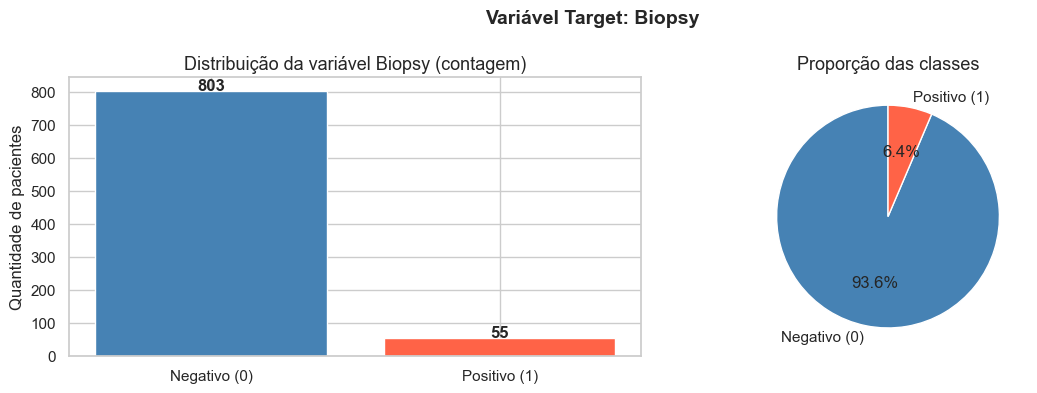

Total de pacientes: 858
Positivos (câncer): 55 (6.4%)
Negativos:          803 (93.6%)


In [72]:
# ─── 2.1 Distribuição da variável target (Biopsy) ───────────────────────────
# Biopsy = 1 → positivo para câncer (classe minoritária)
# Biopsy = 0 → negativo (classe majoritária)
# Datasets médicos costumam ser desbalanceados — isso influencia a escolha da métrica!

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Gráfico de barras com contagem absoluta
counts = df_raw['Biopsy'].value_counts()
axes[0].bar(
    ['Negativo (0)', 'Positivo (1)'],
    counts.values,
    color=['steelblue', 'tomato']
)
axes[0].set_title('Distribuição da variável Biopsy (contagem)')
axes[0].set_ylabel('Quantidade de pacientes')

# Adiciona os valores em cima de cada barra
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 2, str(v), ha='center', fontweight='bold')

# Gráfico de pizza com percentuais
axes[1].pie(
    counts.values,
    labels=['Negativo (0)', 'Positivo (1)'],
    autopct='%1.1f%%',
    colors=['steelblue', 'tomato'],
    startangle=90
)
axes[1].set_title('Proporção das classes')

plt.suptitle('Variável Target: Biopsy', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Total de pacientes: {total}')
print(f'Positivos (câncer): {counts.get(1, 0)} ({counts.get(1, 0)/total*100:.1f}%)')
print(f'Negativos:          {counts.get(0, 0)} ({counts.get(0, 0)/total*100:.1f}%)')

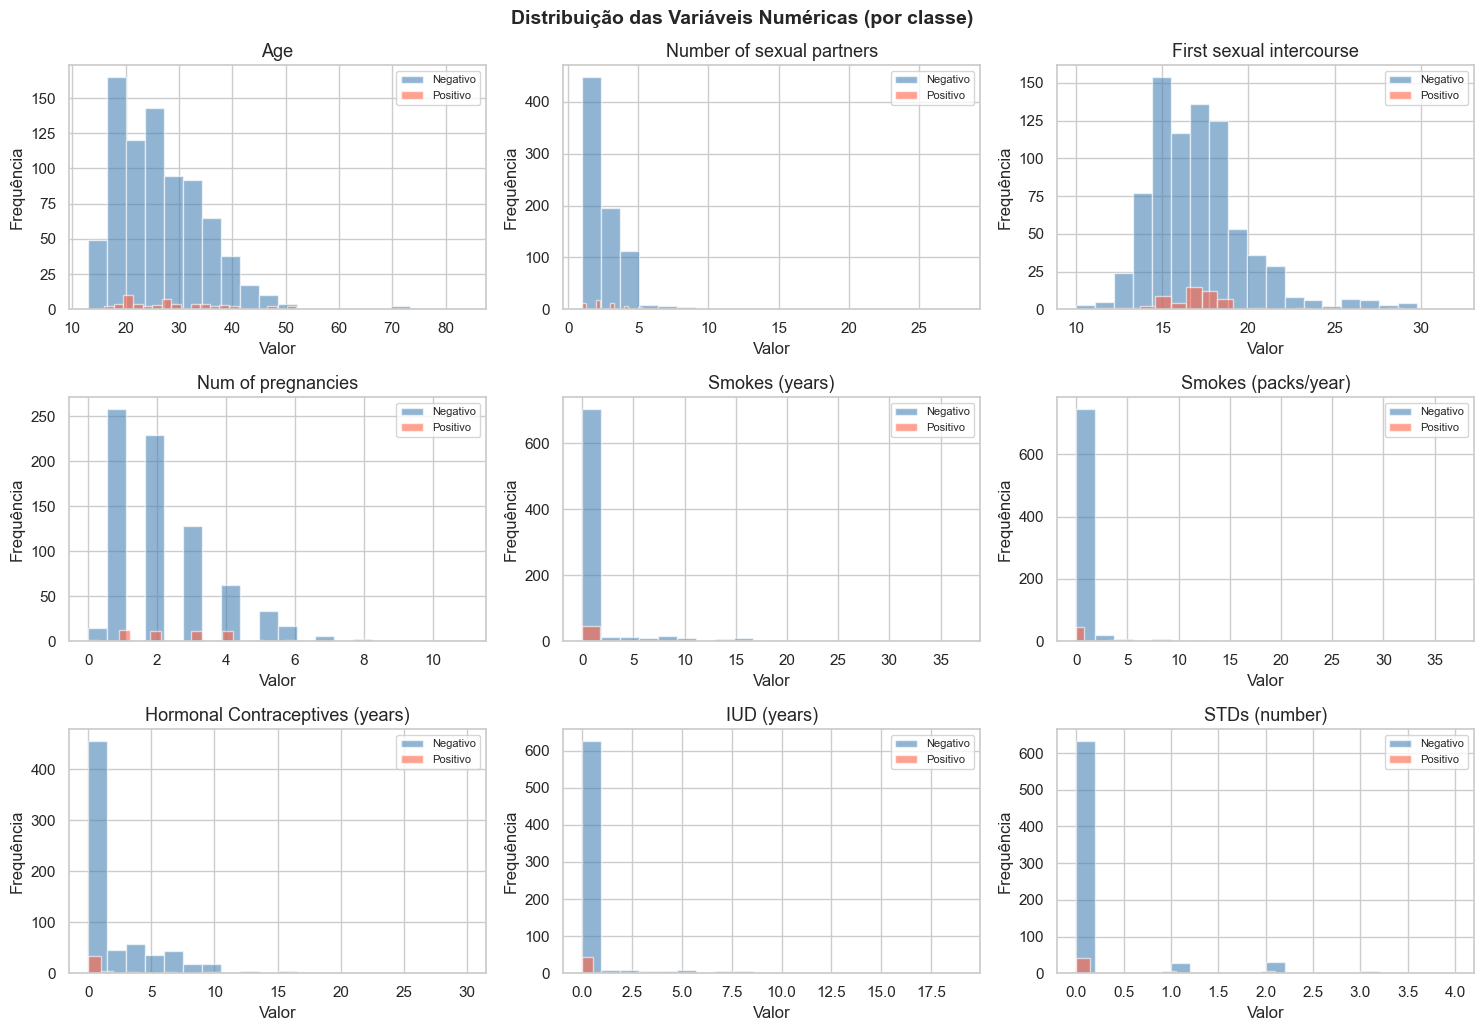

In [73]:
# ─── 2.2 Histogramas das variáveis numéricas ─────────────────────────────────
# Para visualizar as distribuições, primeiro substituímos os '?' por NaN
# Colunas com '?' são convertidas para numérico (NaN onde havia '?')

df_viz = df_raw.replace('?', np.nan)   # Substitui '?' por NaN para visualização

# Converte todas as colunas para numérico (erros → NaN)
for col in df_viz.columns:
    df_viz[col] = pd.to_numeric(df_viz[col], errors='coerce')

# Seleciona apenas as colunas numéricas com variação suficiente
# (exclui colunas binárias simples e o target)
numeric_cols = ['Age', 'Number of sexual partners', 'First sexual intercourse',
                'Num of pregnancies', 'Smokes (years)', 'Smokes (packs/year)',
                'Hormonal Contraceptives (years)', 'IUD (years)', 'STDs (number)']

# Filtra apenas as colunas que existem no dataset
numeric_cols = [c for c in numeric_cols if c in df_viz.columns]

# Plota histogramas em grade
n_cols = 3
n_rows = (len(numeric_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 3.5))
axes = axes.flatten()   # Transforma a grade 2D em lista para iterar

for i, col in enumerate(numeric_cols):
    # Plota histograma colorido pela classe (Biopsy)
    for classe, cor, label in [(0, 'steelblue', 'Negativo'), (1, 'tomato', 'Positivo')]:
        subset = df_viz[df_viz['Biopsy'] == classe][col].dropna()
        axes[i].hist(subset, bins=20, alpha=0.6, color=cor, label=label)
    axes[i].set_title(col)
    axes[i].set_xlabel('Valor')
    axes[i].set_ylabel('Frequência')
    axes[i].legend(fontsize=8)

# Oculta os eixos extras caso a grade tenha células sobrando
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribuição das Variáveis Numéricas (por classe)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

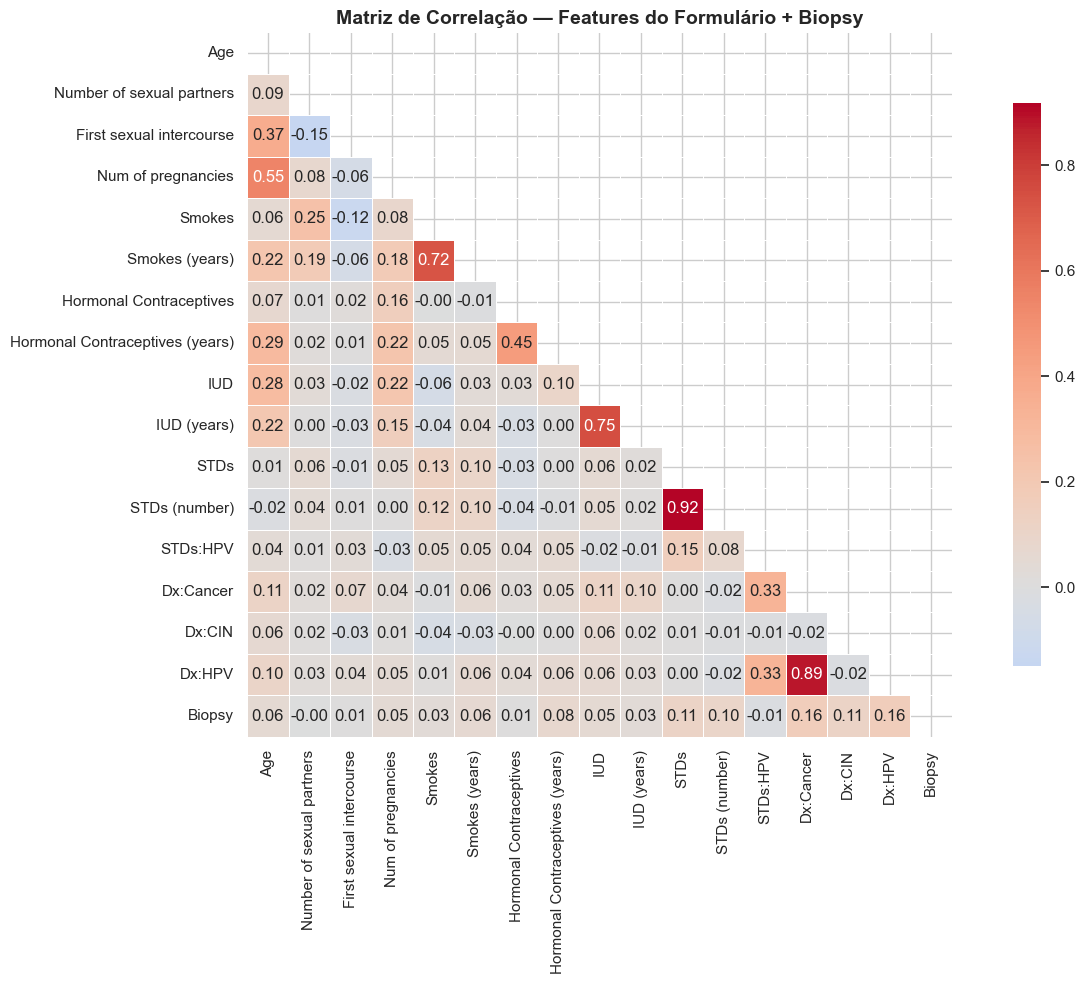

Top correlações com Biopsy:
Dx:Cancer                          0.160905
Dx:HPV                             0.160905
Dx:CIN                             0.113172
STDs                               0.109099
STDs (number)                      0.098347
Hormonal Contraceptives (years)    0.079388
Smokes (years)                     0.062044
Age                                0.055956
IUD                                0.053194
Num of pregnancies                 0.046416
IUD (years)                        0.033275
Smokes                             0.029356
STDs:HPV                          -0.014200
Hormonal Contraceptives            0.007750
First sexual intercourse           0.007264
Number of sexual partners         -0.001442


In [74]:
# ─── 2.3 Heatmap de correlação ───────────────────────────────────────────────
# Correlação de Pearson entre todas as variáveis numéricas
# +1.0 = correlação positiva perfeita
# -1.0 = correlação negativa perfeita
#  0.0 = sem correlação linear
# Focamos nas colunas que o app usa (features do formulário + target)

# Seleciona as features do formulário Streamlit + o target
feature_cols = [
    'Age', 'Number of sexual partners', 'First sexual intercourse',
    'Num of pregnancies', 'Smokes', 'Smokes (years)',
    'Hormonal Contraceptives', 'Hormonal Contraceptives (years)',
    'IUD', 'IUD (years)', 'STDs', 'STDs (number)', 'STDs:HPV',
    'Dx:Cancer', 'Dx:CIN', 'Dx:HPV', 'Biopsy'
]

# Filtra apenas colunas que existem no dataset
feature_cols = [c for c in feature_cols if c in df_viz.columns]

# Calcula a matriz de correlação
corr_matrix = df_viz[feature_cols].corr()

# Plota o heatmap
plt.figure(figsize=(14, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # Oculta o triângulo superior (redundante)

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,         # Exibe o valor numérico em cada célula
    fmt='.2f',          # Formato com 2 casas decimais
    cmap='coolwarm',    # Azul = negativo, Vermelho = positivo
    center=0,           # Centro da escala de cores em 0
    square=True,        # Células quadradas
    linewidths=0.5,
    cbar_kws={'shrink': 0.8}
)
plt.title('Matriz de Correlação — Features do Formulário + Biopsy', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Exibe as features mais correlacionadas com Biopsy
corr_with_target = corr_matrix['Biopsy'].drop('Biopsy').sort_values(key=abs, ascending=False)
print('Top correlações com Biopsy:')
print(corr_with_target.to_string())

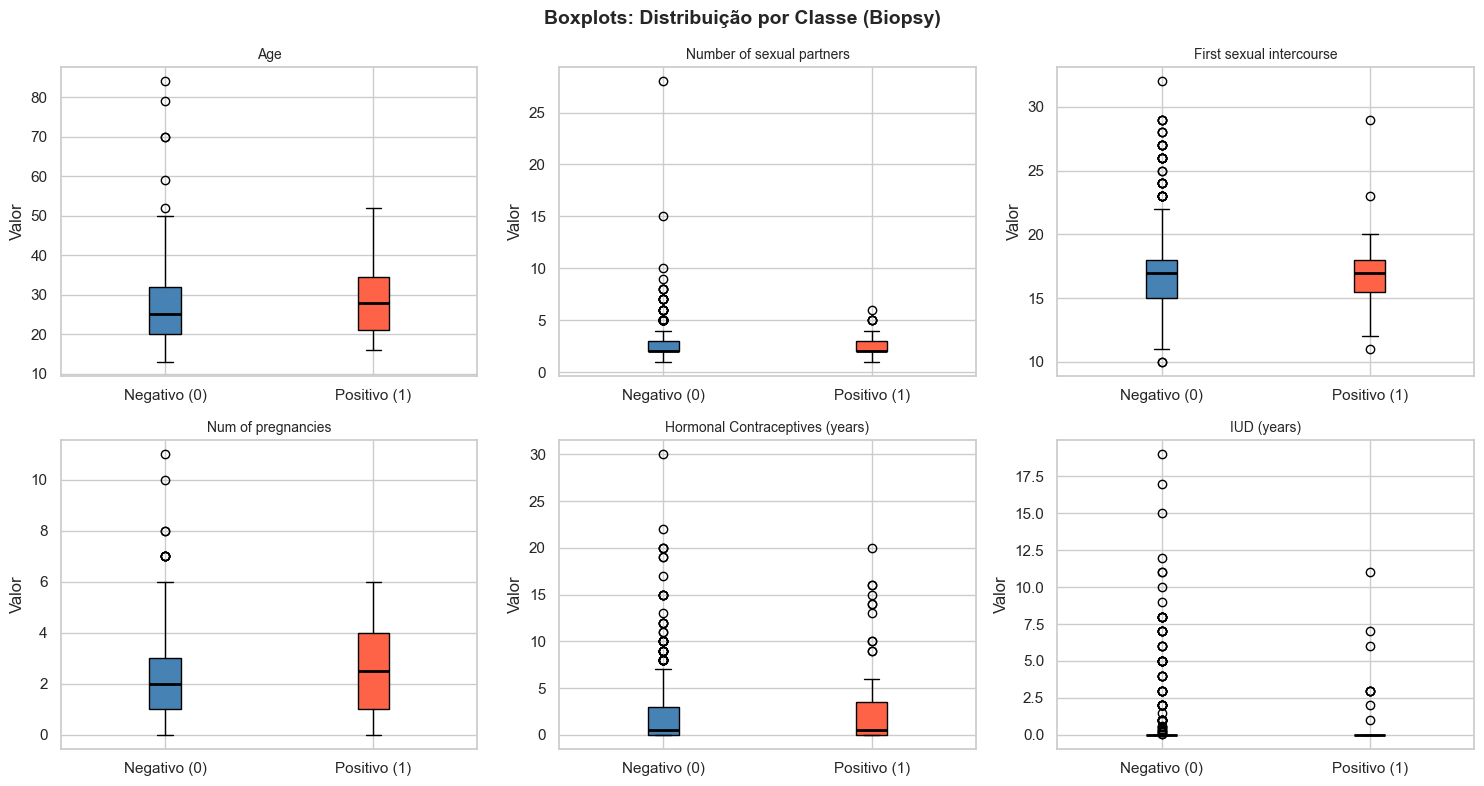

In [75]:
# ─── 2.4 Boxplots das principais variáveis ───────────────────────────────────
# Boxplot compara a distribuição de cada variável entre as classes
# Útil para ver se há diferença significativa entre positivos e negativos

# Seleciona as variáveis contínuas mais relevantes para boxplot
box_cols = ['Age', 'Number of sexual partners', 'First sexual intercourse',
            'Num of pregnancies', 'Hormonal Contraceptives (years)', 'IUD (years)']
box_cols = [c for c in box_cols if c in df_viz.columns]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(box_cols):
    # Prepara os dados agrupados por Biopsy
    data_neg = df_viz[df_viz['Biopsy'] == 0][col].dropna()
    data_pos = df_viz[df_viz['Biopsy'] == 1][col].dropna()

    # Plota o boxplot para cada grupo
    bp = axes[i].boxplot(
        [data_neg, data_pos],
        labels=['Negativo (0)', 'Positivo (1)'],
        patch_artist=True,   # Preenche as caixas com cor
        medianprops={'color': 'black', 'linewidth': 2}
    )

    # Colore as caixas
    bp['boxes'][0].set_facecolor('steelblue')
    bp['boxes'][1].set_facecolor('tomato')

    axes[i].set_title(col, fontsize=10)
    axes[i].set_ylabel('Valor')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Boxplots: Distribuição por Classe (Biopsy)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 3. Pré-processamento

In [76]:
# ─── 3.1 Substituir '?' por NaN ──────────────────────────────────────────────
# O dataset UCI usa '?' como marcador de valor ausente
# Pandas não reconhece '?' como NaN nativamente — precisamos converter manualmente

df = df_raw.replace('?', np.nan).copy()   # Substitui globalmente no DataFrame

print('Antes:')
print(f'  Tipo da coluna "STDs: Time since first diagnosis": {df_raw["STDs: Time since first diagnosis"].dtype}')
print(f'  Exemplo de valor: {df_raw["STDs: Time since first diagnosis"].iloc[0]}')

print('\nDepois:')
print(f'  NaN count total: {df.isna().sum().sum()}')

Antes:
  Tipo da coluna "STDs: Time since first diagnosis": object
  Exemplo de valor: ?

Depois:
  NaN count total: 3622


In [77]:
# ─── 3.2 Converter colunas para tipos corretos ───────────────────────────────
# Após substituir '?' por NaN, convertemos tudo para numérico
# 'errors=coerce' converte erros em NaN (não lança exceção)

for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')   # Converte para float, NaN onde falhar

print('Tipos após conversão:')
print(df.dtypes.value_counts())   # Deve mostrar apenas int64 e float64

print(f'\nValores NaN por coluna (top 10):')
nan_counts = df.isna().sum().sort_values(ascending=False)
print(nan_counts[nan_counts > 0].head(10))

Tipos após conversão:
float64    26
int64      10
Name: count, dtype: int64

Valores NaN por coluna (top 10):
STDs: Time since last diagnosis       787
STDs: Time since first diagnosis      787
IUD                                   117
IUD (years)                           117
Hormonal Contraceptives               108
Hormonal Contraceptives (years)       108
STDs:pelvic inflammatory disease      105
STDs:vulvo-perineal condylomatosis    105
STDs:HPV                              105
STDs:Hepatitis B                      105
dtype: int64


In [78]:
# ─── 3.3 Selecionar as features que o app Streamlit usa ──────────────────────
# O formulário em app/tabs/structured.py coleta exatamente estas 16 features
# Treinamos com as mesmas para garantir compatibilidade com o app

FEATURE_COLS = [
    'Age',                              # Idade da paciente
    'Number of sexual partners',        # Número de parceiros sexuais
    'First sexual intercourse',         # Idade da primeira relação sexual
    'Num of pregnancies',               # Número de gestações
    'Smokes',                           # Fuma? (0/1)
    'Smokes (years)',                   # Anos fumando
    'Hormonal Contraceptives',          # Usa contraceptivo hormonal? (0/1)
    'Hormonal Contraceptives (years)',  # Anos usando contraceptivo hormonal
    'IUD',                              # Usa DIU? (0/1)
    'IUD (years)',                      # Anos com DIU
    'STDs',                             # Histórico de IST? (0/1)
    'STDs (number)',                    # Número de ISTs diferentes
    'STDs:HPV',                         # HPV diagnosticado? (0/1)
    'Dx:Cancer',                        # Diagnóstico prévio de câncer? (0/1)
    'Dx:CIN',                           # Diagnóstico de NIC? (0/1)
    'Dx:HPV',                           # Diagnóstico de HPV em exame? (0/1)
]
TARGET_COL = 'Biopsy'   # Variável target: 1 = positivo para câncer

# Filtra apenas as colunas que existem no dataset
FEATURE_COLS = [c for c in FEATURE_COLS if c in df.columns]
print(f'Features selecionadas ({len(FEATURE_COLS)}):')
for f in FEATURE_COLS:
    print(f'  - {f}')

Features selecionadas (16):
  - Age
  - Number of sexual partners
  - First sexual intercourse
  - Num of pregnancies
  - Smokes
  - Smokes (years)
  - Hormonal Contraceptives
  - Hormonal Contraceptives (years)
  - IUD
  - IUD (years)
  - STDs
  - STDs (number)
  - STDs:HPV
  - Dx:Cancer
  - Dx:CIN
  - Dx:HPV


In [79]:
# ─── 3.4 Imputar valores ausentes com a mediana ──────────────────────────────
# Usamos a mediana (e não a média) porque:
# - A mediana é robusta a outliers (valores extremos)
# - Em dados médicos, outliers são comuns e a média seria distorcida por eles
# IMPORTANTE: o imputer aprende a mediana APENAS nos dados de treino
# depois aplica nos de validação e teste (evita data leakage)

# Separa X (features) e y (target)
X = df[FEATURE_COLS].copy()
y = df[TARGET_COL].copy()

# Remove linhas onde o target é NaN (caso exista)
mask_valid = y.notna()
X = X[mask_valid].reset_index(drop=True)
y = y[mask_valid].reset_index(drop=True)

print(f'X shape: {X.shape}')   # (amostras, features)
print(f'y shape: {y.shape}')   # (amostras,)
print(f'\nDistribuição do target:')
print(y.value_counts())

X shape: (858, 16)
y shape: (858,)

Distribuição do target:
Biopsy
0    803
1     55
Name: count, dtype: int64


In [80]:
# ─── 3.5 Split: 70% treino, 15% validação, 15% teste ────────────────────────
# Estratificado (stratify=y) para manter proporção de positivos em todos os conjuntos
# Isso é crucial em datasets desbalanceados!

# Primeiro split: 70% treino / 30% temporário
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,     # 30% vai para validação + teste
    random_state=42,    # Semente fixa para reprodutibilidade
    stratify=y          # Mantém proporção de positivos
)

# Segundo split: 50% do temporário para validação, 50% para teste
# Resultado: 15% validação e 15% teste do total
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

total_samples = len(X)
print('Divisão dos dados:')
print(f'  Treino:    {len(X_train):4d} amostras ({len(X_train)/total_samples*100:.0f}%)')
print(f'  Validação: {len(X_val):4d} amostras ({len(X_val)/total_samples*100:.0f}%)')
print(f'  Teste:     {len(X_test):4d} amostras ({len(X_test)/total_samples*100:.0f}%)')

# Verifica o balanceamento em cada conjunto
print('\nProporção de positivos (Biopsy=1):')
print(f'  Treino:    {y_train.mean()*100:.1f}%')
print(f'  Validação: {y_val.mean()*100:.1f}%')
print(f'  Teste:     {y_test.mean()*100:.1f}%')

Divisão dos dados:
  Treino:     600 amostras (70%)
  Validação:  129 amostras (15%)
  Teste:      129 amostras (15%)

Proporção de positivos (Biopsy=1):
  Treino:    6.3%
  Validação: 7.0%
  Teste:     6.2%


In [81]:
# ─── 3.6 Imputação e StandardScaler ─────────────────────────────────────────
# Etapa 1: Imputa (preenche) os NaN com a mediana do conjunto de treino
# Etapa 2: Normaliza as features com StandardScaler (média=0, desvio=1)
#
# REGRA DE OURO: fit() APENAS no treino. transform() em todos os conjuntos.
# Se fizermos fit() no dataset inteiro, 'vazamos' informações do teste pro treino.

# Imputer: preenche NaN com a mediana de cada coluna
imputer = SimpleImputer(strategy='median')   # Mediana é robusta a outliers
X_train_imp = imputer.fit_transform(X_train)   # Aprende a mediana do treino e transforma
X_val_imp   = imputer.transform(X_val)          # Aplica a mediana do treino na validação
X_test_imp  = imputer.transform(X_test)         # Aplica a mediana do treino no teste

# Scaler: normaliza para média=0, desvio padrão=1
# Necessário para Logistic Regression (sensível à escala)
# Random Forest e XGBoost são invariantes à escala, mas mantemos para consistência
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imp)   # Aprende a escala do treino
X_val_scaled   = scaler.transform(X_val_imp)          # Aplica a escala do treino
X_test_scaled  = scaler.transform(X_test_imp)         # Aplica a escala do treino

print('✅ Pré-processamento concluído!')
print(f'X_train_scaled shape: {X_train_scaled.shape}')
print(f'X_val_scaled shape:   {X_val_scaled.shape}')
print(f'X_test_scaled shape:  {X_test_scaled.shape}')

✅ Pré-processamento concluído!
X_train_scaled shape: (600, 16)
X_val_scaled shape:   (129, 16)
X_test_scaled shape:  (129, 16)


---
## 4. Treinamento dos Modelos

In [82]:
# ─── 4.1 Definição dos modelos ───────────────────────────────────────────────
# Treinamos 3 modelos com características diferentes:
#
# 1. Logistic Regression:
#    - Modelo linear, interpretável, rápido
#    - Sensível à escala (por isso normalizamos)
#    - Bom baseline para comparar
#
# 2. Random Forest:
#    - Ensemble de árvores de decisão
#    - Robusto, captura não-linearidades
#    - Menos sensível a outliers e escala
#
# 3. XGBoost:
#    - Gradient boosting otimizado
#    - Geralmente o melhor desempenho em dados tabulares
#    - Mais parâmetros para ajustar

models = {
    'Logistic Regression': LogisticRegression(
        C=1.0,              # Inverso da força de regularização
        max_iter=1000,      # Iterações máximas para convergência
        class_weight='balanced',  # Ajusta pesos pelo desbalanceamento das classes
        random_state=42
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=200,   # Número de árvores na floresta
        max_depth=8,        # Profundidade máxima de cada árvore (evita overfitting)
        min_samples_split=5, # Mínimo de amostras para criar um nó
        class_weight='balanced',  # Ajusta pesos pelo desbalanceamento
        random_state=42,
        n_jobs=-1           # Usa todos os cores disponíveis
    ),
    'XGBoost': XGBClassifier(
        n_estimators=200,   # Número de boosting rounds
        max_depth=5,        # Profundidade máxima (mais baixo = menos overfitting)
        learning_rate=0.05, # Taxa de aprendizado (mais baixo = mais conservador)
        subsample=0.8,      # Fração das amostras por árvore
        colsample_bytree=0.8, # Fração das features por árvore
        scale_pos_weight=y_train.value_counts()[0]/y_train.value_counts()[1],  # Lida com desbalanceamento
        eval_metric='logloss',
        random_state=42,
        verbosity=0         # Silencia os logs do XGBoost
    )
}

print('Modelos definidos:')
for name in models:
    print(f'  - {name}')

Modelos definidos:
  - Logistic Regression
  - Random Forest
  - XGBoost


In [83]:
# ─── 4.2 Treinamento ─────────────────────────────────────────────────────────
# Treina cada modelo e avalia no conjunto de validação
# (o conjunto de teste é reservado para a avaliação final — não vemos agora)

trained_models = {}   # Guarda os modelos treinados
val_results = {}      # Guarda as métricas de validação

for name, model in models.items():
    print(f'\nTreinando: {name}...')

    # Treina o modelo nos dados de treino
    model.fit(X_train_scaled, y_train)

    # Predição no conjunto de validação (para comparar modelos)
    y_val_pred = model.predict(X_val_scaled)               # Classes: 0 ou 1
    y_val_proba = model.predict_proba(X_val_scaled)[:, 1]  # Probabilidade da classe 1

    # Calcula as métricas de validação
    val_results[name] = {
        'accuracy': accuracy_score(y_val, y_val_pred),
        'recall':   recall_score(y_val, y_val_pred, zero_division=0),
        'f1':       f1_score(y_val, y_val_pred, zero_division=0),
        'auc_roc':  roc_auc_score(y_val, y_val_proba)
    }

    trained_models[name] = model

    # Exibe as métricas de validação
    r = val_results[name]
    print(f'  Accuracy: {r["accuracy"]:.4f} | Recall: {r["recall"]:.4f} | F1: {r["f1"]:.4f} | AUC-ROC: {r["auc_roc"]:.4f}')

print('\n✅ Treinamento concluído!')


Treinando: Logistic Regression...
  Accuracy: 0.7907 | Recall: 0.4444 | F1: 0.2286 | AUC-ROC: 0.5426

Treinando: Random Forest...
  Accuracy: 0.9147 | Recall: 0.0000 | F1: 0.0000 | AUC-ROC: 0.5880

Treinando: XGBoost...
  Accuracy: 0.9070 | Recall: 0.2222 | F1: 0.2500 | AUC-ROC: 0.5806

✅ Treinamento concluído!


---
## 5. Avaliação Final (conjunto de teste)

In [84]:
# ─── 5.1 Métricas no conjunto de teste ───────────────────────────────────────
# Agora usamos o conjunto de TESTE (nunca visto durante o treinamento)
# Este é o resultado 'honesto' de como o modelo se sairá em produção

test_results = {}   # Guarda os resultados no teste

print('=' * 65)
print('AVALIAÇÃO FINAL — CONJUNTO DE TESTE')
print('=' * 65)

for name, model in trained_models.items():
    # Predição no teste
    y_test_pred  = model.predict(X_test_scaled)               # Classe predita
    y_test_proba = model.predict_proba(X_test_scaled)[:, 1]   # Probabilidade da classe positiva

    # Métricas
    acc    = accuracy_score(y_test, y_test_pred)
    recall = recall_score(y_test, y_test_pred, zero_division=0)
    f1     = f1_score(y_test, y_test_pred, zero_division=0)
    auc    = roc_auc_score(y_test, y_test_proba)

    test_results[name] = {'accuracy': acc, 'recall': recall, 'f1': f1, 'auc_roc': auc}

    print(f'\n{name}:')
    print(f'  Accuracy:  {acc:.4f} ({acc*100:.1f}%)')
    print(f'  Recall:    {recall:.4f} ({recall*100:.1f}%)  ← mais importante!')
    print(f'  F1-Score:  {f1:.4f}')
    print(f'  AUC-ROC:   {auc:.4f}')
    print(f'\n  Relatório completo:')
    print(classification_report(
        y_test, y_test_pred,
        target_names=['Negativo (0)', 'Positivo (1)'],
        zero_division=0
    ))

AVALIAÇÃO FINAL — CONJUNTO DE TESTE

Logistic Regression:
  Accuracy:  0.7984 (79.8%)
  Recall:    0.6250 (62.5%)  ← mais importante!
  F1-Score:  0.2778
  AUC-ROC:   0.7686

  Relatório completo:
              precision    recall  f1-score   support

Negativo (0)       0.97      0.81      0.88       121
Positivo (1)       0.18      0.62      0.28         8

    accuracy                           0.80       129
   macro avg       0.57      0.72      0.58       129
weighted avg       0.92      0.80      0.85       129


Random Forest:
  Accuracy:  0.9380 (93.8%)
  Recall:    0.0000 (0.0%)  ← mais importante!
  F1-Score:  0.0000
  AUC-ROC:   0.6302

  Relatório completo:
              precision    recall  f1-score   support

Negativo (0)       0.94      1.00      0.97       121
Positivo (1)       0.00      0.00      0.00         8

    accuracy                           0.94       129
   macro avg       0.47      0.50      0.48       129
weighted avg       0.88      0.94      0.91       

In [85]:
# ─── 5.2 Tabela comparativa ───────────────────────────────────────────────────
# Compara os 3 modelos lado a lado para fácil visualização

comparison_df = pd.DataFrame(test_results).T   # Linhas = modelos, colunas = métricas
comparison_df = comparison_df.sort_values('recall', ascending=False)  # Ordena por Recall
comparison_df.columns = ['Accuracy', 'Recall', 'F1-Score', 'AUC-ROC']  # Renomeia as colunas

print('\nComparação dos modelos (ordenado por Recall):')
print(comparison_df.to_string(float_format='{:.4f}'.format))

# Identifica o melhor modelo por Recall (nossa métrica principal)
best_model_name = comparison_df['Recall'].idxmax()
print(f'\n🏆 Melhor modelo por Recall: {best_model_name}')


Comparação dos modelos (ordenado por Recall):
                     Accuracy  Recall  F1-Score  AUC-ROC
Logistic Regression    0.7984  0.6250    0.2778   0.7686
XGBoost                0.8992  0.1250    0.1333   0.5651
Random Forest          0.9380  0.0000    0.0000   0.6302

🏆 Melhor modelo por Recall: Logistic Regression


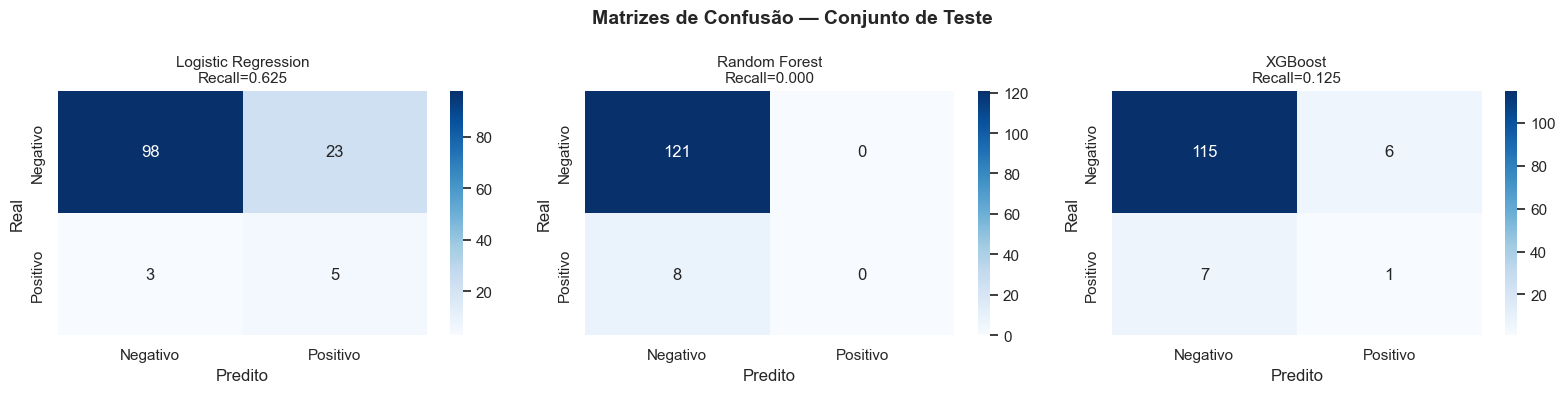

In [86]:
# ─── 5.3 Matrizes de confusão ─────────────────────────────────────────────────
# A matriz de confusão mostra:
#   VP (Verdadeiro Positivo): câncer detectado corretamente
#   VN (Verdadeiro Negativo): negativo confirmado corretamente
#   FP (Falso Positivo):      diagnosticado como câncer, mas era negativo
#   FN (Falso Negativo):      era câncer, mas não foi detectado ← mais perigoso!
# Em diagnóstico médico, minimizar FN (Falso Negativo) é prioridade!

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, (name, model) in zip(axes, trained_models.items()):
    y_pred = model.predict(X_test_scaled)   # Predições no teste
    cm = confusion_matrix(y_test, y_pred)   # Calcula a matriz de confusão

    # Plota como heatmap
    sns.heatmap(
        cm,
        annot=True,        # Exibe os números em cada célula
        fmt='d',           # Formato inteiro
        cmap='Blues',
        ax=ax,
        xticklabels=['Negativo', 'Positivo'],
        yticklabels=['Negativo', 'Positivo']
    )
    ax.set_title(f'{name}\nRecall={test_results[name]["recall"]:.3f}', fontsize=11)
    ax.set_xlabel('Predito')
    ax.set_ylabel('Real')

plt.suptitle('Matrizes de Confusão — Conjunto de Teste', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Por que o Recall é a métrica mais importante?

Em um problema de diagnóstico médico, os erros não têm o mesmo custo:

- **Falso Positivo (FP)**: o modelo diz que a paciente tem câncer, mas ela não tem.  
  → Consequência: exames adicionais, estresse emocional. **Grave, mas tratável.**

- **Falso Negativo (FN)**: o modelo diz que a paciente *não* tem câncer, mas ela tem.  
  → Consequência: a paciente **não recebe tratamento** e a doença progride.  
  → Pode ser **fatal**.

O **Recall** (também chamado de *Sensibilidade* ou *True Positive Rate*) mede exatamente a capacidade do modelo de encontrar os casos positivos reais:

$$\text{Recall} = \frac{\text{VP}}{\text{VP} + \text{FN}}$$

Queremos **maximizar o Recall** para minimizar os Falsos Negativos.  
Aceitamos um Recall mais alto mesmo que isso aumente um pouco o número de Falsos Positivos.

---
## 6. Explicabilidade com SHAP

In [87]:
# ─── 6.1 SHAP Values — Visão global das features ─────────────────────────────
# SHAP (SHapley Additive exPlanations) explica cada predição do modelo
# mostrando quanto cada feature contribuiu para o resultado
#
# Valores SHAP positivos → aumentam a probabilidade de câncer
# Valores SHAP negativos → diminuem a probabilidade de câncer
#
# Usamos o melhor modelo identificado anteriormente

best_model = trained_models[best_model_name]
print(f'Gerando SHAP values para: {best_model_name}')

# Cria o explainer adequado ao tipo do modelo
if best_model_name in ('Random Forest', 'XGBoost'):
    # TreeExplainer é mais eficiente para modelos baseados em árvores
    explainer = shap.TreeExplainer(best_model)
else:
    # LinearExplainer para modelos lineares como Logistic Regression
    explainer = shap.LinearExplainer(best_model, X_train_scaled)

# Calcula os SHAP values para o conjunto de teste
shap_values = explainer.shap_values(X_test_scaled)

# Para modelos binários, shap_values pode ser uma lista [classe_0, classe_1]
# Usamos os valores da classe 1 (positivo para câncer)
if isinstance(shap_values, list):
    shap_vals = shap_values[1]   # Índice 1 = classe positiva
else:
    shap_vals = shap_values

print(f'SHAP values shape: {shap_vals.shape}')

Gerando SHAP values para: Logistic Regression
SHAP values shape: (129, 16)


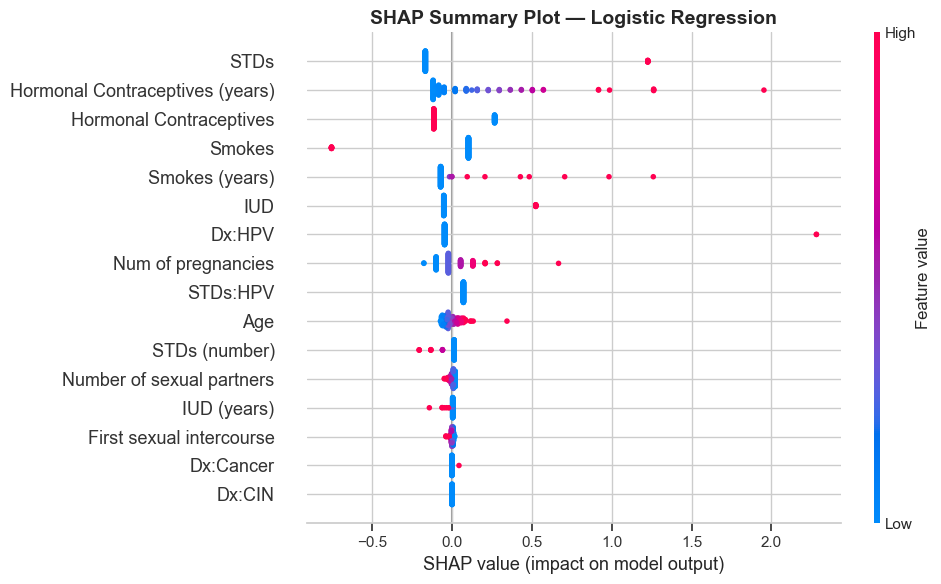

In [88]:
# ─── 6.2 Gráfico Summary Plot (importância global das features) ──────────────
# Mostra a distribuição dos SHAP values de cada feature para todos os exemplos
# Cada ponto = uma amostra de teste
# Cor vermelha = valor alto da feature; azul = valor baixo
# Posição no eixo X = impacto no resultado (positivo = aumenta risco)

plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_vals,
    X_test_scaled,
    feature_names=FEATURE_COLS,
    show=False,
    plot_size=(10, 6)
)
plt.title(f'SHAP Summary Plot — {best_model_name}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

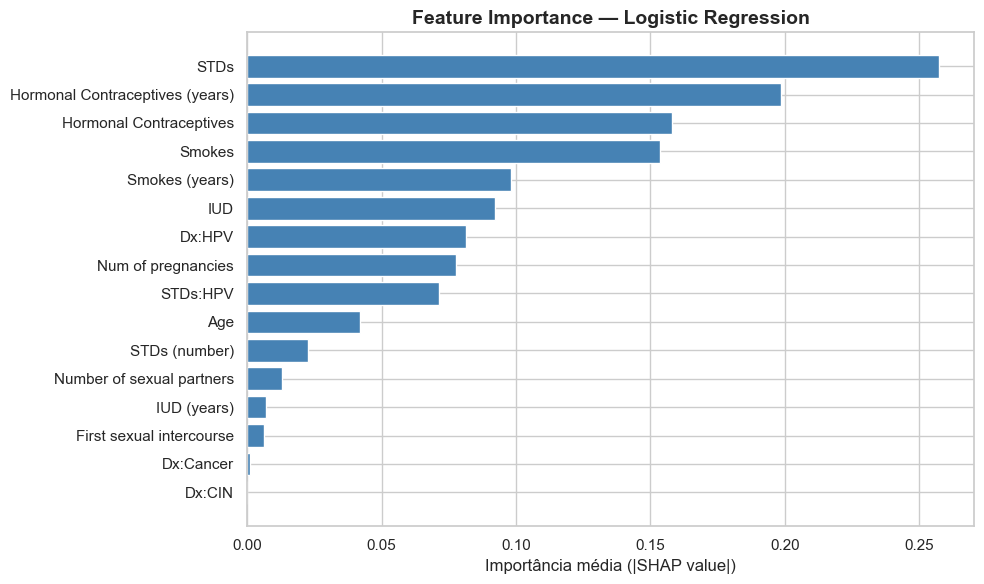

Top 5 features mais importantes:
                        feature  importance
                           STDs    0.257457
Hormonal Contraceptives (years)    0.198517
        Hormonal Contraceptives    0.158110
                         Smokes    0.153469
                 Smokes (years)    0.098209


In [89]:
# ─── 6.3 Feature Importance (valor absoluto médio dos SHAP values) ────────────
# Mostra quais features têm MAIOR IMPACTO MÉDIO nas predições do modelo
# Independente de ser positivo ou negativo — só a magnitude importa aqui

# Calcula a importância média absoluta de cada feature
mean_abs_shap = np.abs(shap_vals).mean(axis=0)   # Média dos valores absolutos

# Cria um DataFrame para facilitar a visualização
importance_df = pd.DataFrame({
    'feature': FEATURE_COLS,
    'importance': mean_abs_shap
}).sort_values('importance', ascending=True)   # Ascendente para barh ficar em ordem decrescente

# Plota o gráfico de barras horizontais
plt.figure(figsize=(10, 6))
plt.barh(
    importance_df['feature'],
    importance_df['importance'],
    color='steelblue'
)
plt.xlabel('Importância média (|SHAP value|)')
plt.title(f'Feature Importance — {best_model_name}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('Top 5 features mais importantes:')
print(importance_df.sort_values('importance', ascending=False).head(5).to_string(index=False))

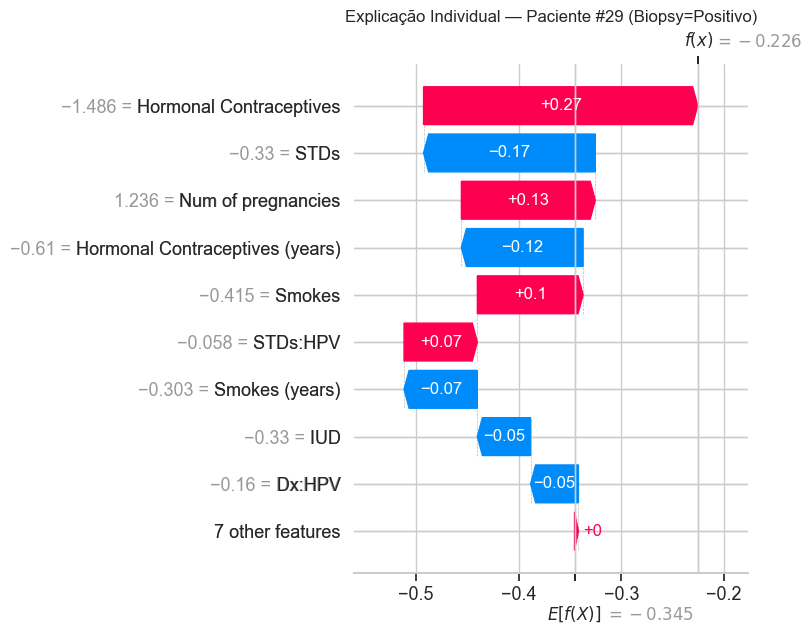

In [90]:
# ─── 6.4 Waterfall Plot — Explicação de uma predição individual ───────────────
# Mostra como o modelo chegou à predição para UM ÚNICO paciente
# Cada barra mostra a contribuição de cada feature para esta predição específica
# Útil para explicar o resultado ao médico: 'o HPV foi o principal fator'

# Seleciona o primeiro caso positivo do conjunto de teste para exemplificar
positive_indices = np.where(y_test == 1)[0]  # Índices de casos positivos

if len(positive_indices) > 0:
    idx = positive_indices[0]   # Pega o primeiro caso positivo

    # Cria o objeto de explicação para um único exemplo
    explanation = shap.Explanation(
        values=shap_vals[idx],              # SHAP values deste exemplo
        base_values=explainer.expected_value if not isinstance(explainer.expected_value, list)
                    else explainer.expected_value[1],
        data=X_test_scaled[idx],            # Valores das features
        feature_names=FEATURE_COLS
    )

    plt.figure(figsize=(10, 5))
    shap.waterfall_plot(explanation, show=False, max_display=10)
    plt.title(f'Explicação Individual — Paciente #{idx} (Biopsy=Positivo)', fontsize=12)
    plt.tight_layout()
    plt.show()
else:
    print('Nenhum caso positivo no conjunto de teste para este exemplo.')

---
## 7. Salvando os Modelos

In [91]:
# ─── 7.1 Salva cada modelo individualmente ────────────────────────────────────
# Os modelos são salvos em formato .pkl (pickle) com joblib
# O Streamlit carrega esses arquivos para fazer predições em tempo real
# IMPORTANTE: salvar também o scaler e o imputer para usar no app!

# Mapeamento do nome do modelo para o nome do arquivo
model_filenames = {
    'Logistic Regression': 'logistic_regression.pkl',
    'Random Forest':       'random_forest.pkl',
    'XGBoost':             'xgboost.pkl',
}

# Salva cada modelo treinado
for name, model in trained_models.items():
    filename = model_filenames[name]
    path = os.path.join(ARTIFACTS_PATH, filename)
    joblib.dump(model, path)   # Serializa o modelo para arquivo .pkl
    print(f'✅ {name} salvo em: {path}')

# Salva o scaler (necessário para normalizar os dados de entrada no app)
scaler_path = os.path.join(ARTIFACTS_PATH, 'scaler.pkl')
joblib.dump(scaler, scaler_path)
print(f'✅ Scaler salvo em: {scaler_path}')

# Salva o imputer (necessário para tratar NaN nos dados de entrada do app)
imputer_path = os.path.join(ARTIFACTS_PATH, 'imputer.pkl')
joblib.dump(imputer, imputer_path)
print(f'✅ Imputer salvo em: {imputer_path}')

# Salva a lista de features usadas no treinamento
# O app precisa saber a ordem exata das colunas!
features_path = os.path.join(ARTIFACTS_PATH, 'feature_names.pkl')
joblib.dump(FEATURE_COLS, features_path)
print(f'✅ Feature names salvas em: {features_path}')

✅ Logistic Regression salvo em: C:\Users\dhieg\Desktop\IAPARADEV\modulo1\app\models\artifacts\logistic_regression.pkl
✅ Random Forest salvo em: C:\Users\dhieg\Desktop\IAPARADEV\modulo1\app\models\artifacts\random_forest.pkl
✅ XGBoost salvo em: C:\Users\dhieg\Desktop\IAPARADEV\modulo1\app\models\artifacts\xgboost.pkl
✅ Scaler salvo em: C:\Users\dhieg\Desktop\IAPARADEV\modulo1\app\models\artifacts\scaler.pkl
✅ Imputer salvo em: C:\Users\dhieg\Desktop\IAPARADEV\modulo1\app\models\artifacts\imputer.pkl
✅ Feature names salvas em: C:\Users\dhieg\Desktop\IAPARADEV\modulo1\app\models\artifacts\feature_names.pkl


In [92]:
# ─── 7.2 Verificação final ────────────────────────────────────────────────────
# Confirma que todos os arquivos foram criados corretamente

print('Arquivos salvos em:', ARTIFACTS_PATH)
print()

for f in sorted(os.listdir(ARTIFACTS_PATH)):
    fpath = os.path.join(ARTIFACTS_PATH, f)
    size_kb = os.path.getsize(fpath) / 1024   # Tamanho em KB
    print(f'  {f:<40} {size_kb:>8.1f} KB')

print()
print('✅ Pipeline completo! Modelos prontos para uso no Streamlit.')
print('   Execute: streamlit run app/main.py')

Arquivos salvos em: C:\Users\dhieg\Desktop\IAPARADEV\modulo1\app\models\artifacts

  feature_names.pkl                             0.3 KB
  imputer.pkl                                   1.2 KB
  logistic_regression.pkl                       1.0 KB
  random_forest.pkl                          1019.5 KB
  scaler.pkl                                    1.0 KB
  xgboost.pkl                                 307.3 KB

✅ Pipeline completo! Modelos prontos para uso no Streamlit.
   Execute: streamlit run app/main.py


In [93]:
# ─── 7.3 Teste rápido de carregamento ─────────────────────────────────────────
# Valida que os modelos salvos podem ser carregados e fazem predições
# Simula exatamente o que o app Streamlit fará

print('Testando carregamento dos modelos...')

# Carrega os artefatos salvos
loaded_rf       = joblib.load(os.path.join(ARTIFACTS_PATH, 'random_forest.pkl'))
loaded_scaler   = joblib.load(os.path.join(ARTIFACTS_PATH, 'scaler.pkl'))
loaded_imputer  = joblib.load(os.path.join(ARTIFACTS_PATH, 'imputer.pkl'))
loaded_features = joblib.load(os.path.join(ARTIFACTS_PATH, 'feature_names.pkl'))

# Cria um exemplo de paciente fictício (como viria do formulário Streamlit)
exemplo_paciente = {
    'Age': 35,
    'Number of sexual partners': 3,
    'First sexual intercourse': 17,
    'Num of pregnancies': 2,
    'Smokes': 1,
    'Smokes (years)': 5,
    'Hormonal Contraceptives': 1,
    'Hormonal Contraceptives (years)': 3,
    'IUD': 0,
    'IUD (years)': 0,
    'STDs': 1,
    'STDs (number)': 1,
    'STDs:HPV': 1,
    'Dx:Cancer': 0,
    'Dx:CIN': 0,
    'Dx:HPV': 1
}

# Converte para DataFrame com as colunas na ordem correta
input_df = pd.DataFrame([exemplo_paciente])[loaded_features]

# Aplica o mesmo pipeline de pré-processamento do treino
input_imp    = loaded_imputer.transform(input_df)      # Imputa NaN (se houver)
input_scaled = loaded_scaler.transform(input_imp)      # Normaliza

# Faz a predição
pred  = loaded_rf.predict(input_scaled)[0]
proba = loaded_rf.predict_proba(input_scaled)[0]

print(f'\nPaciente exemplo:')
for k, v in exemplo_paciente.items():
    print(f'  {k}: {v}')

print(f'\nPredição: {"Positivo (câncer)" if pred == 1 else "Negativo"}')
print(f'Probabilidade: {proba[1]*100:.1f}%')
print('\n✅ Carregamento e predição funcionando corretamente!')

Testando carregamento dos modelos...

Paciente exemplo:
  Age: 35
  Number of sexual partners: 3
  First sexual intercourse: 17
  Num of pregnancies: 2
  Smokes: 1
  Smokes (years): 5
  Hormonal Contraceptives: 1
  Hormonal Contraceptives (years): 3
  IUD: 0
  IUD (years): 0
  STDs: 1
  STDs (number): 1
  STDs:HPV: 1
  Dx:Cancer: 0
  Dx:CIN: 0
  Dx:HPV: 1

Predição: Negativo
Probabilidade: 13.2%

✅ Carregamento e predição funcionando corretamente!
